In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [2]:
import numpy
from ExoRM import read_rm_data, load_model, ForecasterRM, preprocess_data
import matplotlib.pyplot as plot

plot.style.use('seaborn-v0_8')

data = read_rm_data()
data = preprocess_data(data)
data

,radius,mass,density
0,18.647000,2543.000000,0.392211
1,16.140960,4417.837000,1.050562
2,1.910000,8.080000,1.159608
3,4.203375,57.209400,0.770323
4,3.240000,13.600000,0.399856
...,...,...,...
1488,15.356304,225.658169,0.062315
1489,13.787046,7024.007795,2.680225
1490,11.130518,6356.568140,4.609742
1491,18.494850,2224.810000,0.351674


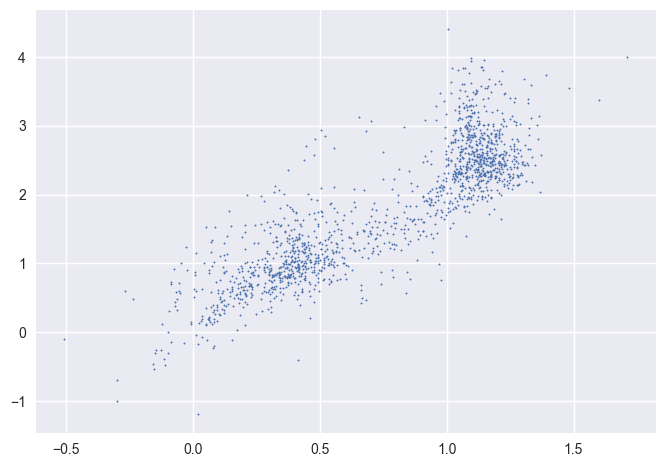

In [3]:
x = data['radius']
y = data['mass']

x = numpy.log10(x)
y = numpy.log10(y)

plot.scatter(x, y, s = 1)

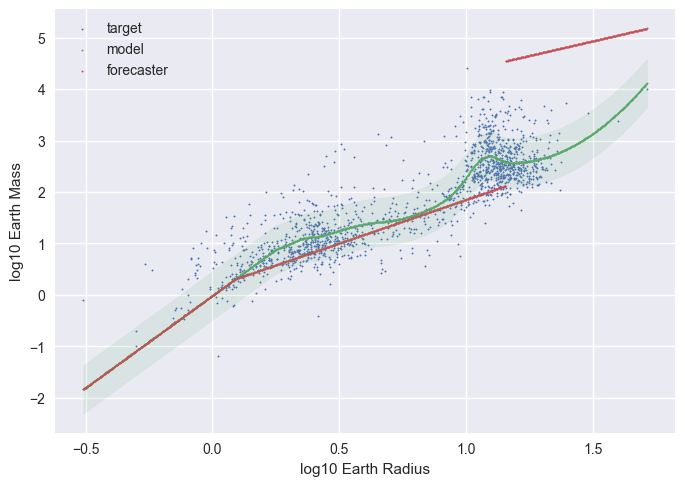

In [4]:
model = load_model()

xs = numpy.linspace(x.min(), x.max(), 1000)

ms = model(xs)

ms2 = ForecasterRM.forecaster(xs)

plot.scatter(x, y, s = 1)
plot.scatter(xs, ms, s = 1)
plot.scatter(xs, ms2, s = 1)

plot.fill_between(xs, ms - model.error, ms + model.error, color = 'C1', alpha = 0.1)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('log10 Earth Radius')
plot.ylabel('log10 Earth Mass')

plot.show()

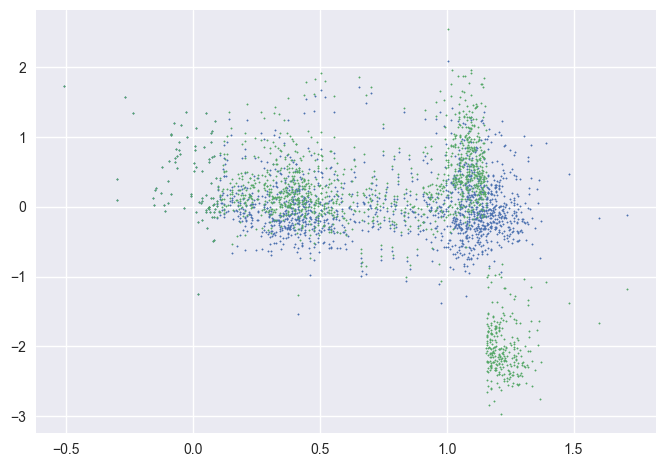

In [5]:
m = model(x)
m2 = ForecasterRM.forecaster(x)

r = y - m
r2 = y - m2
plot.scatter(x, r, s = 1)
plot.scatter(x, r2, s = 1)
plot.show()

In [6]:
print(numpy.std(r))
print(numpy.std(r2))

0.4480485693699388
1.0284002188504964


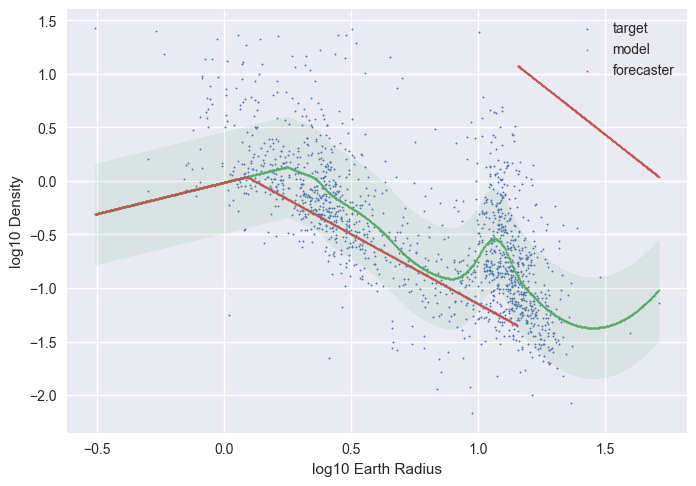

In [7]:
plot.scatter(x, numpy.log10((10 ** y) / ((10 ** x) ** 3)), s = 1)
plot.scatter(xs, numpy.log10((10 ** ms) / ((10 ** xs) ** 3)), s = 1)
plot.scatter(xs, numpy.log10((10 ** ms2) / ((10 ** xs) ** 3)), s = 1)

plot.fill_between(xs,
                  numpy.log10((10 ** (ms - model.error)) / ((10 ** xs) ** 3)),
                  numpy.log10((10 ** (ms + model.error)) / ((10 ** xs) ** 3)), color = 'C1', alpha = 0.1)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('log10 Earth Radius')
plot.ylabel('log10 Density')

plot.show()